# Data Analytics
# Seaborn Assessment 
**Modules 7–10: NumPy, Pandas, Matplotlib and Seaborn**

**Student:** Sagar Gupta



## Section A – Concept Application

### 1. NumPy vectorisation
For 50,000 distances, vectorisation is better than a Python `for` loop because NumPy performs operations on the whole array efficiently. Broadcasting allows a scalar such as `5` to be applied to every distance without manually looping through the array. A Python loop can still be useful when every row needs complicated custom logic that is difficult to express as NumPy operations.

### 2. Pandas groupby and agg
`groupby()` and `agg()` are better than looping restaurant by restaurant because the operation is designed for grouped data and is shorter and easier to maintain.

```python
df.groupby('restaurant_name').agg({
    'order_value': 'mean',
    'delivery_time_mins': 'mean',
    'rating': 'mean'
})
```

The resulting index represents the unique restaurant names.

### 3. Matplotlib chart choices
- Monthly orders: **line chart**, because it shows a trend over time.
- Cuisine proportions: **pie chart**, because the categories represent parts of a total.
- Delivery times: **histogram**, because it shows the distribution of a numeric variable.

`plt.subplots(1, 3)` can arrange the three charts in one row. A shared x-axis is not suitable because the three plots use different x-axis meanings.

### 4. Annotation
I would find the maximum using `np.argmax()` and then use `plt.annotate()` with `xy` for the peak location and `xytext` for the position of the label. `arrowprops` controls the arrow and `text` contains the displayed message.

### 5. Boxplot vs violinplot
For 10,000 observations and three categories, I would choose a **boxplot** for the main report because it clearly shows median, quartiles and potential outliers. The rating scale is discrete from 1–5, so the extra density shape of a violin plot can be less useful. A violin plot would be preferable when I want to inspect the detailed shape of a continuous distribution.

### 6. Correlation heatmap
A correlation heatmap shows Pearson correlation values between numeric variables. A value close to `+1` means a strong positive relationship, while a value close to `-1` means a strong negative relationship. I would investigate absolute correlations around `0.8` or higher as a possible multicollinearity warning. This is a practical rule of thumb rather than a strict law.


## Section B – Task 1: Delivery Fee Array Calculator (NumPy)

In [1]:
import numpy as np

np.random.seed(42)

# Generate 25 delivery distances
distances = np.random.uniform(1.0, 15.0, 25)

# Vectorised fee calculation
fees = 20 + 5 * distances

# Boolean indexing
mask = fees > 60

print("Orders where delivery fee is above Rs 60:")
for distance, fee in zip(distances[mask], fees[mask]):
    print(f"Distance: {distance:.2f} km | Fee: Rs {fee:.2f}")

print("\nFee statistics")
print(f"Minimum fee: Rs {np.min(fees):.2f}")
print(f"Maximum fee: Rs {np.max(fees):.2f}")
print(f"Mean fee: Rs {np.mean(fees):.2f}")
print(f"Standard deviation: Rs {np.std(fees):.2f}")


Orders where delivery fee is above Rs 60:
Distance: 14.31 km | Fee: Rs 91.55
Distance: 11.25 km | Fee: Rs 76.24
Distance: 9.38 km | Fee: Rs 66.91
Distance: 13.13 km | Fee: Rs 85.63
Distance: 9.42 km | Fee: Rs 67.08
Distance: 10.91 km | Fee: Rs 74.57
Distance: 14.58 km | Fee: Rs 92.89
Distance: 12.65 km | Fee: Rs 83.27
Distance: 8.35 km | Fee: Rs 61.73
Distance: 9.57 km | Fee: Rs 67.83

Fee statistics
Minimum fee: Rs 26.44
Maximum fee: Rs 92.89
Mean fee: Rs 55.86
Standard deviation: Rs 19.56


## Section B – Task 2: Restaurant Performance Analyser (Pandas)

In [2]:
import pandas as pd
import numpy as np

np.random.seed(10)

restaurants = ['Spice Hub', 'Burger Point', 'Biryani House', 'Dragon Bowl', 'Pizza Corner']
cities = ['Mumbai', 'Ahmedabad', 'Surat']
cuisines = ['Indian', 'Fast Food', 'Chinese']

rows = []
for i in range(40):
    rows.append({
        'restaurant_name': restaurants[i % 5],
        'city': cities[i % 3],
        'order_value': np.random.randint(200, 1000),
        'delivery_time_mins': np.random.randint(20, 46),
        'rating': round(np.random.uniform(3.2, 5.0), 1),
        'cuisine_type': cuisines[i % 3]
    })

restaurant_df = pd.DataFrame(rows)

summary = (
    restaurant_df
    .groupby('restaurant_name')
    .agg(
        mean_order_value=('order_value', 'mean'),
        mean_delivery_time=('delivery_time_mins', 'mean'),
        mean_rating=('rating', 'mean')
    )
)

final_result = (
    summary[
        (summary['mean_rating'] > 4.0) &
        (summary['mean_delivery_time'] < 35)
    ]
    .sort_values('mean_order_value', ascending=False)
    .reset_index()
)

print(final_result.to_string(index=False))


Empty DataFrame
Columns: [restaurant_name, mean_order_value, mean_delivery_time, mean_rating]
Index: []


## Section B – Task 3: Monthly Order Trend Dashboard (Matplotlib)

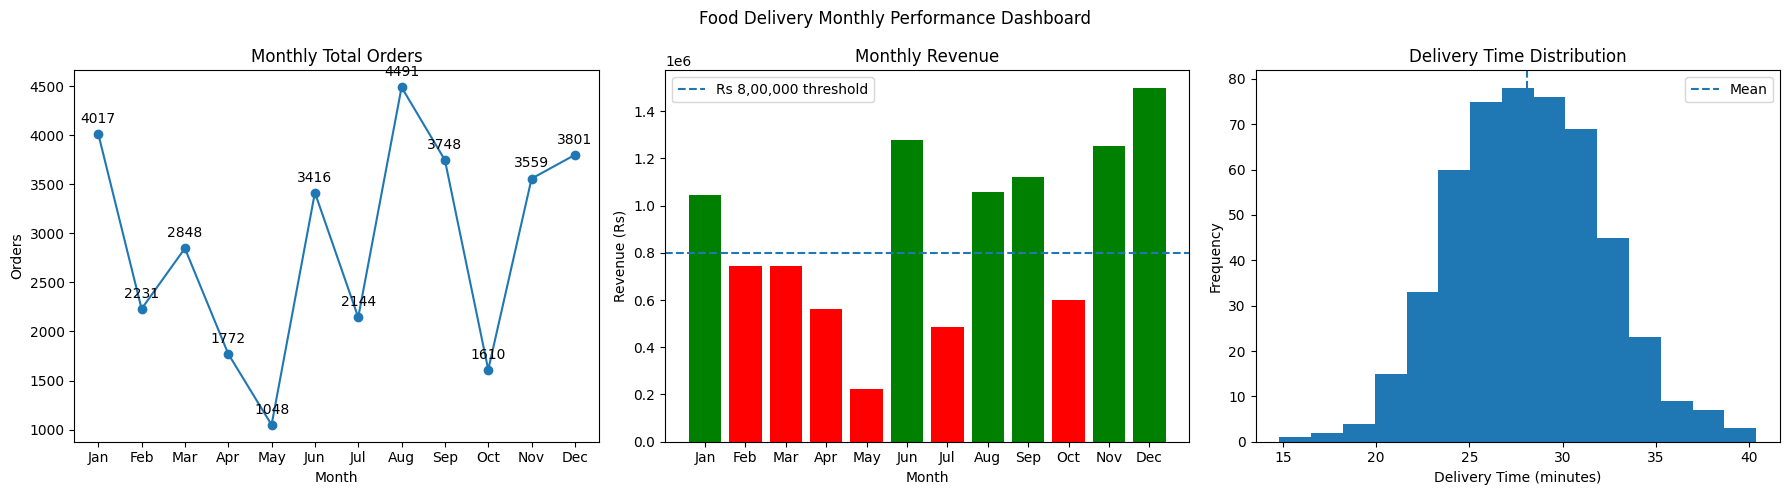

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(21)

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

orders = np.random.randint(1000, 5001, 12)
avg_order_value = np.random.uniform(200, 400, 12)
revenue = orders * avg_order_value
delivery_times = np.random.normal(28, 4, 500)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Subplot 1 - Line chart
axes[0].plot(months, orders, marker='o')
for month, value in zip(months, orders):
    axes[0].annotate(
        str(value),
        xy=(month, value),
        xytext=(0, 8),
        textcoords='offset points',
        ha='center'
    )
axes[0].set_title('Monthly Total Orders')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Orders')

# Subplot 2 - Bar chart
bar_colors = ['green' if value > 800000 else 'red' for value in revenue]
axes[1].bar(months, revenue, color=bar_colors)
axes[1].axhline(800000, linestyle='--', label='Rs 8,00,000 threshold')
axes[1].set_title('Monthly Revenue')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Revenue (Rs)')
axes[1].legend()

# Subplot 3 - Histogram
axes[2].hist(delivery_times, bins=15)
sample_mean = np.mean(delivery_times)
axes[2].axvline(sample_mean, linestyle='--', label='Mean')
axes[2].set_title('Delivery Time Distribution')
axes[2].set_xlabel('Delivery Time (minutes)')
axes[2].set_ylabel('Frequency')
axes[2].legend()

fig.suptitle('Food Delivery Monthly Performance Dashboard')
plt.tight_layout()
plt.savefig('food_delivery_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()


## Section B – Task 4: Full EDA Pipeline

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(7)

n = 200

eda_df = pd.DataFrame({
    'order_value': np.random.uniform(100, 800, n),
    'distance_km': np.random.uniform(1, 20, n),
    'delivery_time_mins': np.random.normal(30, 8, n),
    'rating': np.random.uniform(1.0, 5.0, n),
    'discount_pct': np.random.uniform(0, 30, n)
})

# Keep delivery time positive for a sensible speed calculation
eda_df['delivery_time_mins'] = eda_df['delivery_time_mins'].clip(lower=5)

# Introduce about 5% nulls in the two requested columns
rng = np.random.default_rng(7)

for column in ['delivery_time_mins', 'rating']:
    null_indices = rng.choice(eda_df.index, size=10, replace=False)
    eda_df.loc[null_indices, column] = np.nan

# Fill nulls with column medians
eda_df['delivery_time_mins'] = eda_df['delivery_time_mins'].fillna(
    eda_df['delivery_time_mins'].median()
)
eda_df['rating'] = eda_df['rating'].fillna(
    eda_df['rating'].median()
)

# Derived speed column
eda_df['delivery_speed_kmph'] = (
    eda_df['distance_km'] / (eda_df['delivery_time_mins'] / 60)
)

# Three equal-frequency speed bands
eda_df['speed_band'] = pd.qcut(
    eda_df['delivery_speed_kmph'],
    q=3,
    labels=['Slow', 'Normal', 'Fast']
)

print(eda_df.head())
print("\nNull values after cleaning:")
print(eda_df.isnull().sum())


   order_value  distance_km  delivery_time_mins    rating  discount_pct  \
0   153.415803    15.287118           29.436359  1.610398     17.079069   
1   645.943155     2.171641           41.143419  1.247733      4.256927   
2   406.886462    15.151650           20.002291  3.285994     18.347489   
3   606.425624    18.979243           18.019293  1.749068     29.233717   
4   784.592658    12.467631           24.767687  3.171931      8.202608   

   delivery_speed_kmph speed_band  
0            31.159664       Fast  
1             3.166934       Slow  
2            45.449742       Fast  
3            63.196404       Fast  
4            30.202978       Fast  

Null values after cleaning:
order_value            0
distance_km            0
delivery_time_mins     0
rating                 0
discount_pct           0
delivery_speed_kmph    0
speed_band             0
dtype: int64


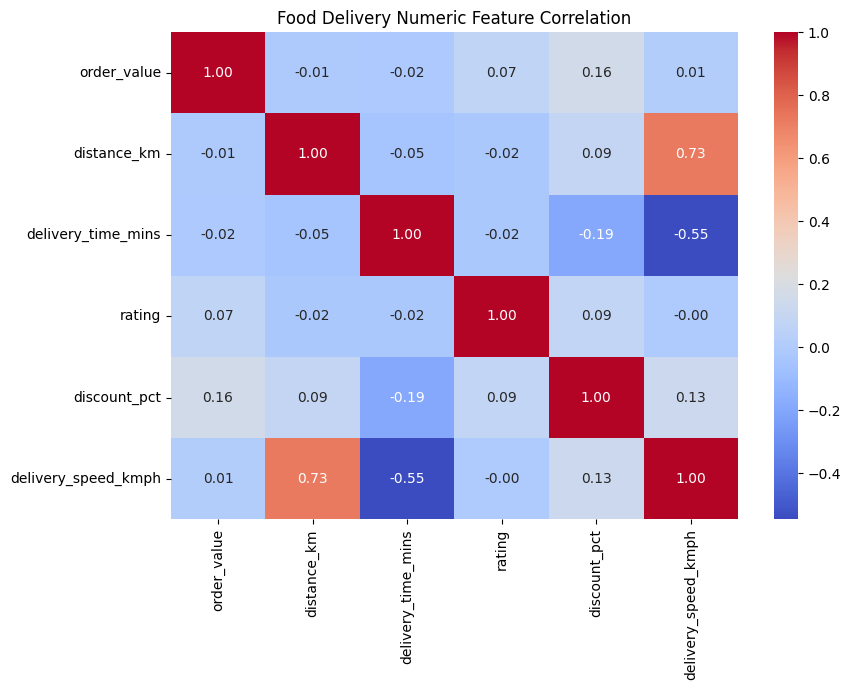

In [5]:
# Correlation heatmap
numeric_df = eda_df.select_dtypes(include=np.number)
correlation = numeric_df.corr(method='pearson')

plt.figure(figsize=(9, 7))
sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Food Delivery Numeric Feature Correlation')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()


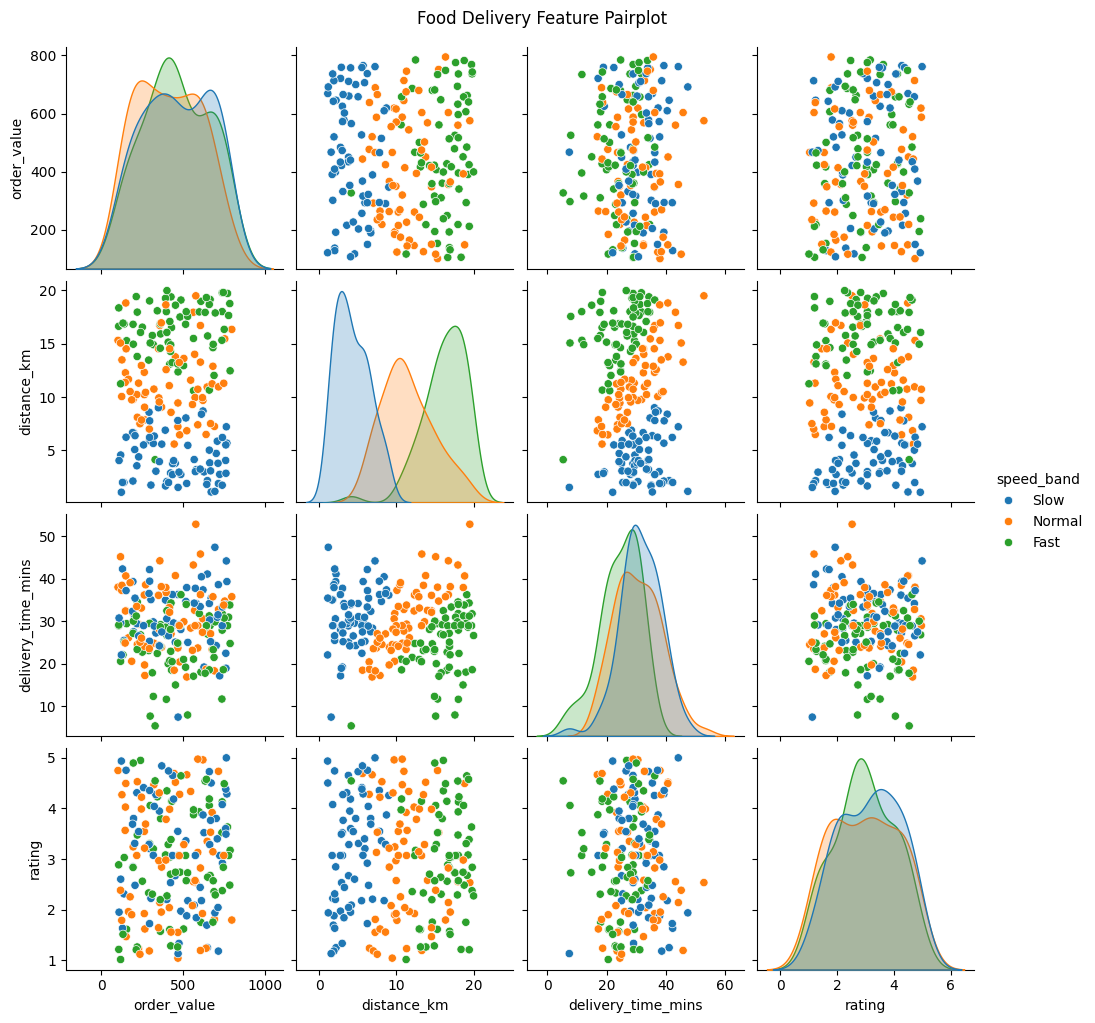

In [6]:
# Pairplot
pairplot = sns.pairplot(
    eda_df,
    vars=['order_value', 'distance_km', 'delivery_time_mins', 'rating'],
    hue='speed_band'
)
pairplot.fig.suptitle('Food Delivery Feature Pairplot', y=1.02)
pairplot.savefig('pairplot.png', dpi=200, bbox_inches='tight')
plt.show()


## Section C – Mini Capstone Project: Food Delivery Analytics Console

The menu has four analysis options and exits with `5`. Each analysis is implemented as a separate function. Charts are saved as PNG files and are not displayed during menu operation.


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(25)

restaurants = ['Spice Hub', 'Burger Point', 'Biryani House', 'Dragon Bowl', 'Pizza Corner']
cities = ['Mumbai', 'Ahmedabad', 'Surat']
cuisines = ['Indian', 'Fast Food', 'Chinese']

n = 200
capstone_df = pd.DataFrame({
    'restaurant_name': np.random.choice(restaurants, n),
    'city': np.random.choice(cities, n),
    'cuisine_type': np.random.choice(cuisines, n),
    'order_value': np.random.uniform(150, 900, n),
    'distance_km': np.random.uniform(1, 20, n),
    'delivery_time_mins': np.random.normal(30, 7, n),
    'rating': np.random.uniform(1, 5, n),
    'discount_pct': np.random.uniform(0, 30, n)
})

capstone_df['delivery_time_mins'] = capstone_df['delivery_time_mins'].clip(lower=5)

# Fill numeric nulls before analysis
for column in capstone_df.select_dtypes(include=np.number).columns:
    if capstone_df[column].isnull().any():
        capstone_df[column] = capstone_df[column].fillna(capstone_df[column].median())

def summary_statistics():
    print("\nSummary Statistics")
    print(capstone_df.select_dtypes(include=np.number).describe().round(2))
    print("\nMean order value:", round(np.mean(capstone_df['order_value']), 2))
    print("Std. deviation of order value:", round(np.std(capstone_df['order_value']), 2))

def distribution_analysis():
    plt.figure(figsize=(8, 5))
    plt.hist(capstone_df['delivery_time_mins'], bins=15)
    plt.title('Delivery Time Distribution')
    plt.xlabel('Delivery Time (minutes)')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.savefig('menu_distribution_analysis.png', dpi=150)
    plt.close()
    print("Chart saved as menu_distribution_analysis.png")

def correlation_heatmap():
    numeric = capstone_df.select_dtypes(include=np.number)
    corr = numeric.corr()
    plt.figure(figsize=(9, 7))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap')
    plt.tight_layout()
    plt.savefig('menu_correlation_heatmap.png', dpi=150)
    plt.close()
    print("Chart saved as menu_correlation_heatmap.png")

def restaurant_performance():
    result = (
        capstone_df.groupby('restaurant_name')
        .agg(
            mean_rating=('rating', 'mean'),
            mean_order_value=('order_value', 'mean'),
            mean_delivery_time=('delivery_time_mins', 'mean')
        )
        .sort_values('mean_rating', ascending=False)
    )
    print(result.round(2))

    plt.figure(figsize=(8, 5))
    plt.bar(result.index, result['mean_rating'])
    plt.title('Restaurant Performance - Mean Rating')
    plt.xlabel('Restaurant')
    plt.ylabel('Mean Rating')
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.savefig('menu_restaurant_performance.png', dpi=150)
    plt.close()
    print("Chart saved as menu_restaurant_performance.png")

def final_report():
    top3 = (
        capstone_df.groupby('restaurant_name')['rating']
        .mean()
        .sort_values(ascending=False)
        .head(3)
    )

    numeric = capstone_df.select_dtypes(include=np.number)
    corr = numeric.corr().abs()
    np.fill_diagonal(corr.values, np.nan)
    max_pair = corr.stack().idxmax()
    max_value = corr.stack().max()

    print("\nFINAL SUMMARY REPORT")
    print("---------------------")
    print("Top 3 restaurants by mean rating:")
    print(top3.round(2))
    print(
        f"\nHighest absolute Pearson correlation: "
        f"{max_pair[0]} and {max_pair[1]} = {max_value:.3f}"
    )
    print(
        f"Overall mean delivery time: "
        f"{np.mean(capstone_df['delivery_time_mins']):.2f} minutes"
    )
    print(
        f"Overall standard deviation of delivery time: "
        f"{np.std(capstone_df['delivery_time_mins']):.2f} minutes"
    )

def run_menu():
    while True:
        print("\nFOOD DELIVERY ANALYTICS")
        print("1. Summary Statistics")
        print("2. Distribution Analysis")
        print("3. Correlation Heatmap")
        print("4. Restaurant Performance Report")
        print("5. Exit")

        choice = input("Enter your choice: ")

        if choice == '1':
            summary_statistics()
        elif choice == '2':
            distribution_analysis()
        elif choice == '3':
            correlation_heatmap()
        elif choice == '4':
            restaurant_performance()
        elif choice == '5':
            final_report()
            print("\nProgram ended.")
            break
        else:
            print("Please enter a valid option.")

# Uncomment the next line to run the interactive menu in VS Code/Jupyter.
# run_menu()


## Section D – AI-Augmented Learning

### Step 1 – Exact prompt
> Write a Python 3 program using NumPy and Pandas to create a synthetic food delivery dataset with at least 5 numeric columns and one categorical column called cuisine_type. Then create a Seaborn pairplot of all numeric columns coloured by cuisine_type and save it as a PNG. Also calculate the Pearson correlation matrix and create a Seaborn heatmap with annotated values and a diverging colour palette. Save the heatmap as a separate PNG at DPI 200.

### AI original code
The first version generated the data and charts, but it did not explicitly remove/fill null values before using the categorical column in the pairplot and the heatmap save settings were not kept consistent.

### Corrected version


In [8]:
# Corrected Section D solution

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(100)

d = pd.DataFrame({
    'order_value': np.random.uniform(100, 1000, 150),
    'distance_km': np.random.uniform(1, 20, 150),
    'delivery_time_mins': np.random.normal(30, 6, 150),
    'rating': np.random.uniform(1, 5, 150),
    'discount_pct': np.random.uniform(0, 30, 150),
    'restaurant_age_years': np.random.randint(1, 15, 150),
    'cuisine_type': np.random.choice(
        ['Indian', 'Chinese', 'Fast Food'],
        150
    )
})

d['delivery_time_mins'] = d['delivery_time_mins'].clip(lower=5)

# Check and handle numeric nulls
for col in d.select_dtypes(include=np.number).columns:
    d[col] = d[col].fillna(d[col].median())

# Categorical null handling
d['cuisine_type'] = d['cuisine_type'].fillna('Unknown')

# Pairplot
pair = sns.pairplot(
    d,
    hue='cuisine_type',
    diag_kind='hist'
)
pair.fig.suptitle('Food Delivery Numeric Features by Cuisine', y=1.02)
pair.savefig('ai_pairplot_corrected.png', dpi=200, bbox_inches='tight')
plt.close('all')

# Correlation heatmap
numeric_columns = d.select_dtypes(include=np.number)
corr = numeric_columns.corr(method='pearson')

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)
plt.title('Food Delivery Pearson Correlation Heatmap')
plt.tight_layout()
plt.savefig('ai_correlation_heatmap_corrected.png', dpi=200, bbox_inches='tight')
plt.close()

print("AI Section D charts saved successfully.")


AI Section D charts saved successfully.


### Step 2 – Test and Debug Note

I tested the solution and made the data types and missing-value handling explicit before creating the plots. I also set `dpi=200` on both saved charts so the output meets the assessment requirement. Filling the categorical column is important because a null category can cause missing observations in the pairplot. The corrected version also selects only numeric columns for the Pearson correlation matrix.
